# Abstract

# Introduction and Background

# Data Used

In [72]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Machine Learning Packages
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression 

In [73]:
file_location = '/Users/diegocardenas/GroupProject/GroupProjectData101/Diego/csv-Copy1/COVID clinical trials.csv'
DF_Covid = pd.read_csv(file_location,na_filter=False)
show(DF_Covid)

Loading ITables v2.5.2 from the internet... (need help?)


# Exploratory Data Analysis

In [65]:
show(DF_Covid)

Loading ITables v2.5.2 from the internet... (need help?)


In [32]:
DF_Covid.columns

Index(['Rank', 'NCT Number', 'Title', 'Acronym', 'Status', 'Study Results',
       'Conditions', 'Interventions', 'Outcome Measures',
       'Sponsor/Collaborators', 'Gender', 'Age', 'Phases', 'Enrollment',
       'Funded Bys', 'Study Type', 'Study Designs', 'Other IDs', 'Start Date',
       'Primary Completion Date', 'Completion Date', 'First Posted',
       'Results First Posted', 'Last Update Posted', 'Locations',
       'Study Documents', 'URL'],
      dtype='object')

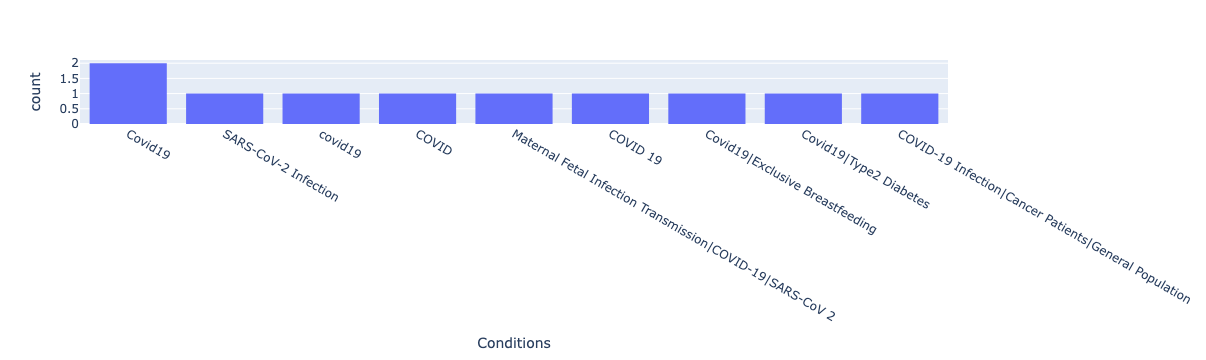

In [55]:
mask = DF_Covid['Conditions'].head(10)

fig = px.histogram(mask, x = 'Conditions')

fig.show()

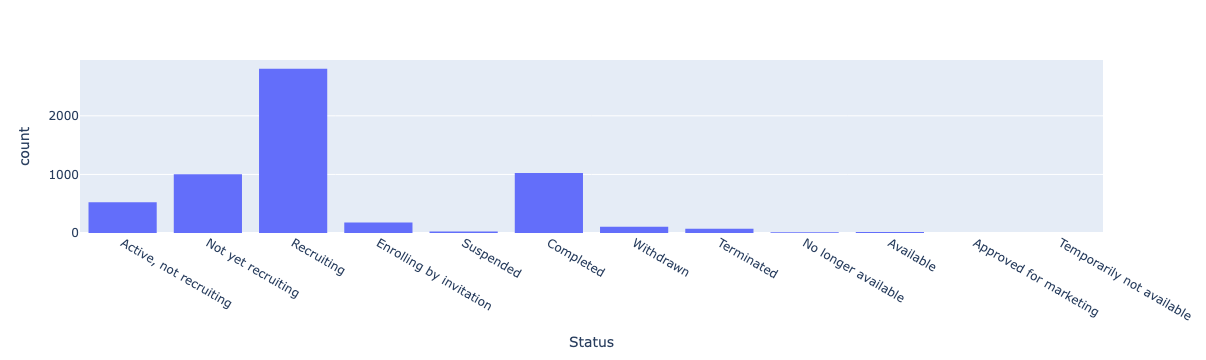

In [53]:

fig = px.histogram(DF_Covid, x = 'Status')

fig.show()

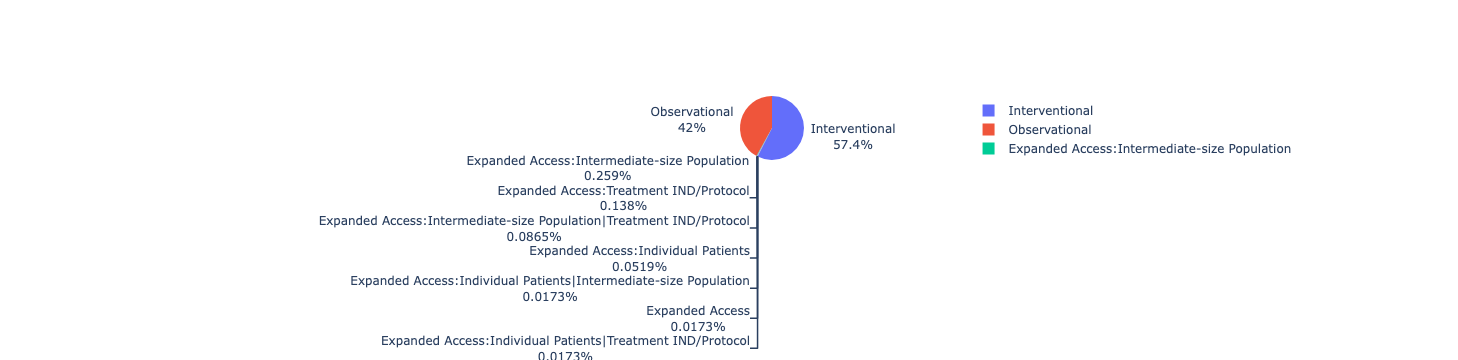

In [68]:
import plotly.graph_objects as go

labels = DF_Covid['Study Type'].value_counts().index
values = DF_Covid['Study Type'].value_counts().values
fig = go.Figure(data=[go.Pie(labels=labels, values=values, textinfo='label+percent',
                             insidetextorientation='radial')])
fig.show()



In [58]:
path = '/Users/diegocardenas/GroupProject/GroupProjectData101/csv/COVID clinical trials.csv'

# Read in data

df_covid = pd.DataFrame()
df = pd.DataFrame()
i=0
list_keywords=[]

for file in list_of_files:
    file_path=path+file
    #print('Processing....'+file_path)
    tree = ElementTree.parse(file_path)
    root = tree.getroot()

    trial = {}

    trial['id'] = root.find('id_info').find('nct_id').text
    trial['overall_status'] = root.find('overall_status').text
    trial['study_type'] = root.find('study_type').text
    
    if root.find('start_date') != None:
        trial['start_date'] = root.find('start_date').text
    else:
         trial['start_date'] = ''
        
    if root.find('enrollment') != None:
        trial['enrollment'] = root.find('enrollment').text
    else:
         trial['enrollment'] = ''

    trial['condition'] = root.find('condition').text.upper().replace('CORONAVIRUS INFECTIONS','CORONAVIRUS INFECTION').replace('CORONA VIRUS INFECTION','CORONAVIRUS INFECTION').replace('SARS-COV-2','SARS-COV2').replace('SARS-COV 2','SARS-COV2').replace('COVID-19','COVID').replace('COVID19','COVID').replace('COVID 19','COVID')
    if root.find('location_countries') != None:
        trial['location_countries'] = root.find('location_countries').find('country').text.upper()
    else:
        trial['location_countries'] = ''
        
    if root.find('intervention') != None:
        trial['intervention'] = root.find('intervention').find('intervention_name').text.upper()
    else:
        trial['intervention'] = ''
        
    #trial['description'] = root.find('brief_summary')[0].text
    for entry in root.findall('keyword'):
        list_keywords.append(entry.text)

    if root.find('official_title') == None:
        trial['title'] = root.find('brief_title').text
    else:
        trial['title'] = root.find('official_title').text

    date_string = root.find('required_header').find('download_date').text
    trial['date_processed'] = date_string.replace('ClinicalTrials.gov processed this data on ', '')
    
    trial['sponsors'] = root.find('sponsors').find('lead_sponsor').find('agency').text
    
    
    df  = pd.DataFrame(trial,index=[i])
    i=i+1
    
    df_covid = pd.concat([df_covid, df])

NameError: name 'list_of_files' is not defined